# **1. Understand the Problem Formulation**

This is a supervised regression problem:

- Input: Multivariate time series (sensor + settings)
- Output: RUL (Remaining Useful Life)

Mathematically:

- RLU = failure cycle − current cycle

Key nuance:

- Train → full degradation until failure
- Test → truncated sequences (you must predict remaining cycles)

# **Libraries**

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

import warnings
warnings.filterwarnings('ignore')

# **Loading Dataset**

In [2]:
cols = ['unit', 'cycle'] + [f'op{i}' for i in range(1,4)] + [f's{i}' for i in range(1,22)]

train = pd.read_csv("train_FD001.txt", sep="\s+", header=None)
train.columns = cols

test = pd.read_csv("test_FD001.txt", sep="\s+", header=None)
test.columns = cols

y_test = pd.read_csv('RUL_FD001.txt',  header=None, names=['RUL'])

rul = pd.read_csv("RUL_FD001.txt", header=None)

# **EDA**

In [3]:
print(train.head())
print(train.shape)

   unit  cycle     op1     op2    op3      s1      s2       s3       s4  \
0     1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1     1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2     1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3     1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4     1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      s5  ...     s12      s13      s14     s15   s16  s17   s18    s19  \
0  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392  2388  100.0   
1  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392  2388  100.0   
2  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390  2388  100.0   
3  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392  2388  100.0   
4  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393  2388  100.0   

     s20      s21  
0  39.06  23.4190  
1  39.00  23.4236  
2  38.95  23.3442  
3  38.88  23.3739 

In [4]:
print("\nInfo:")
train.info()


Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   unit    20631 non-null  int64  
 1   cycle   20631 non-null  int64  
 2   op1     20631 non-null  float64
 3   op2     20631 non-null  float64
 4   op3     20631 non-null  float64
 5   s1      20631 non-null  float64
 6   s2      20631 non-null  float64
 7   s3      20631 non-null  float64
 8   s4      20631 non-null  float64
 9   s5      20631 non-null  float64
 10  s6      20631 non-null  float64
 11  s7      20631 non-null  float64
 12  s8      20631 non-null  float64
 13  s9      20631 non-null  float64
 14  s10     20631 non-null  float64
 15  s11     20631 non-null  float64
 16  s12     20631 non-null  float64
 17  s13     20631 non-null  float64
 18  s14     20631 non-null  float64
 19  s15     20631 non-null  float64
 20  s16     20631 non-null  float64
 21  s17     20631 non-null  int6

In [5]:
print("\nMissing Values:")
print(train.isnull().sum())


Missing Values:
unit     0
cycle    0
op1      0
op2      0
op3      0
s1       0
s2       0
s3       0
s4       0
s5       0
s6       0
s7       0
s8       0
s9       0
s10      0
s11      0
s12      0
s13      0
s14      0
s15      0
s16      0
s17      0
s18      0
s19      0
s20      0
s21      0
dtype: int64


## **Generate RUL**

In [6]:
max_cycle = train.groupby('unit')['cycle'].max().reset_index()
max_cycle.columns = ['unit', 'max_cycle']

In [7]:
train = train.merge(max_cycle, on='unit')
train['RUL'] = train['max_cycle'] - train['cycle']

# Clip RUL at 125
train['RUL'] = train['RUL'].clip(upper=125)

In [8]:
train['RUL'].head(10)

0    125
1    125
2    125
3    125
4    125
5    125
6    125
7    125
8    125
9    125
Name: RUL, dtype: int64

## **RUL Distribution**

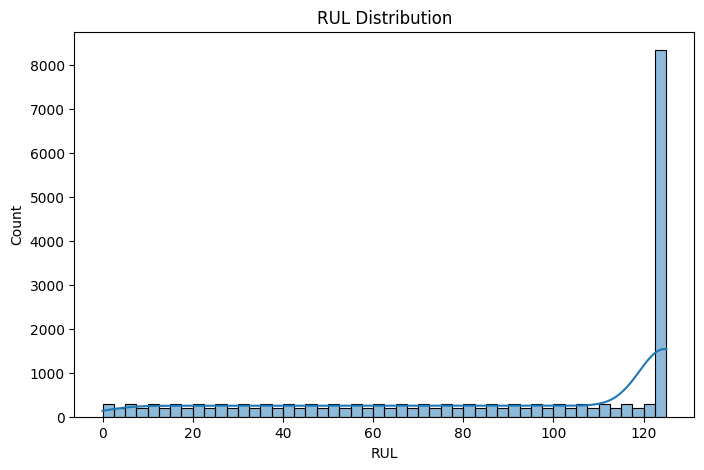

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(train['RUL'], bins=50, kde=True)
plt.title("RUL Distribution")
plt.show()

## **Engine-wise Lifecycle**

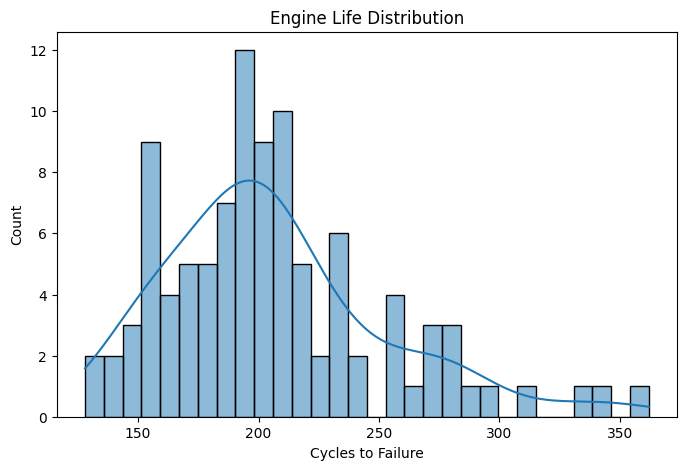

In [10]:
engine_life = train.groupby('unit')['cycle'].max()

plt.figure(figsize=(8,5))
sns.histplot(engine_life, bins=30, kde=True)
plt.title("Engine Life Distribution")
plt.xlabel("Cycles to Failure")
plt.show()

## **Sensor Variance (Drop Low Variance Sensors)**

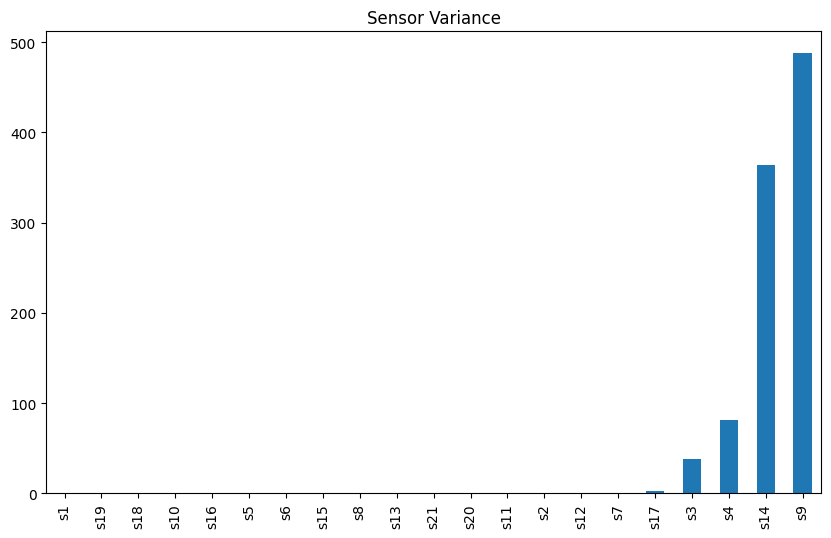

In [11]:
sensor_cols = [col for col in train.columns if col.startswith('s')]

variance = train[sensor_cols].var().sort_values()

plt.figure(figsize=(10,6))
variance.plot(kind='bar')
plt.title("Sensor Variance")
plt.show()

In [12]:
low_var_sensors = variance[variance < 1e-3].index.tolist()
print("Low Variance Sensors:", low_var_sensors)

Low Variance Sensors: ['s1', 's19', 's18', 's10', 's16', 's5', 's6']


In [13]:
# drop the low variance near zero sensors

train.drop(columns=low_var_sensors, inplace=True)
test.drop(columns=low_var_sensors, inplace=True)

sensor_cols = [c for c in train.columns if c.startswith('s')]

## **Correlation with RUL**

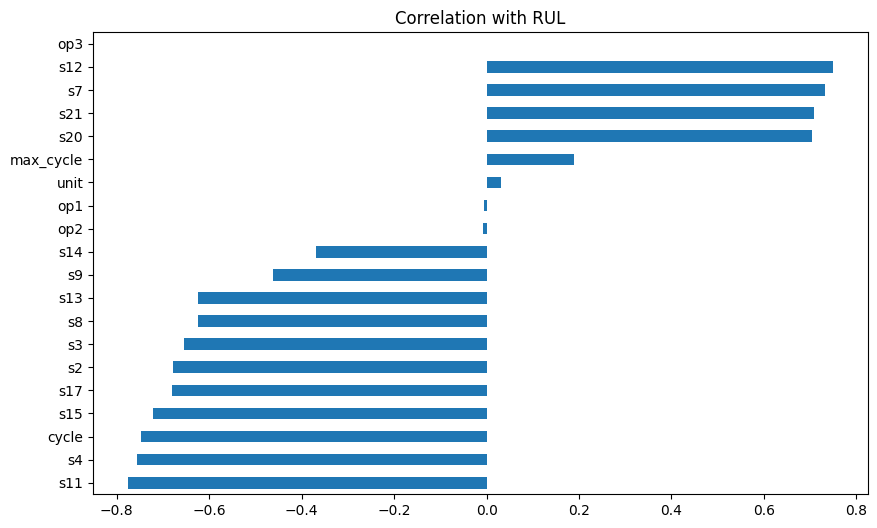

In [14]:
corr = train.corr()
rul_corr = corr['RUL'].drop('RUL').sort_values()

plt.figure(figsize=(10,6))
rul_corr.plot(kind='barh')
plt.title("Correlation with RUL")
plt.show()

## **Heatmap (Top Features Only)**

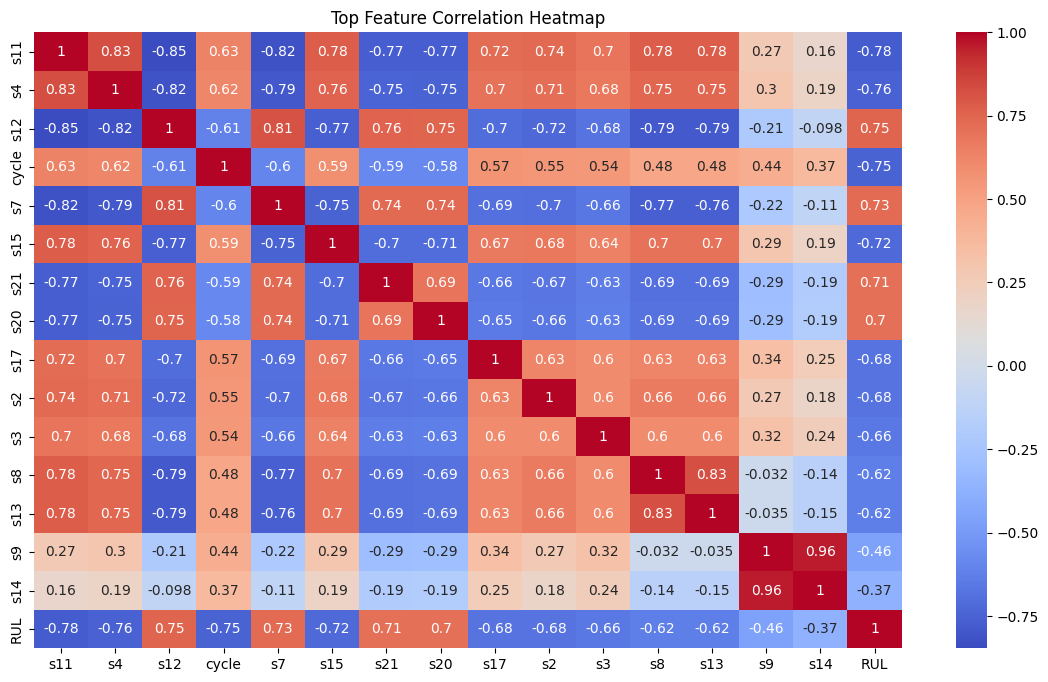

In [15]:
top_features = rul_corr.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(14,8))
sns.heatmap(train[top_features.tolist() + ['RUL']].corr(), annot=True, cmap='coolwarm')
plt.title("Top Feature Correlation Heatmap")
plt.show()

## **Sensor Trends (Degradation Visualization)**

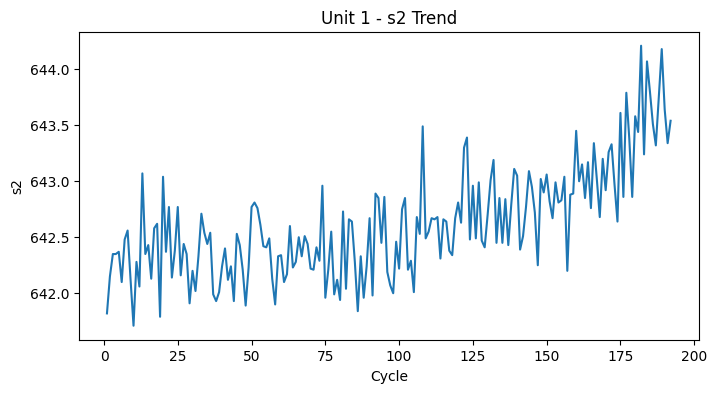

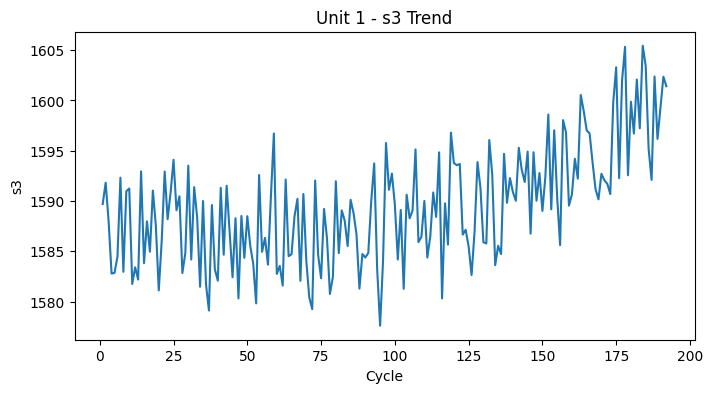

In [16]:
def plot_sensor(unit_id, sensor='s2'):
    temp = train[train['unit'] == unit_id]
    plt.figure(figsize=(8,4))
    plt.plot(temp['cycle'], temp[sensor])
    plt.title(f"Unit {unit_id} - {sensor} Trend")
    plt.xlabel("Cycle")
    plt.ylabel(sensor)
    plt.show()

plot_sensor(1, 's2')
plot_sensor(1, 's3')

## **Operating Conditions Effect**

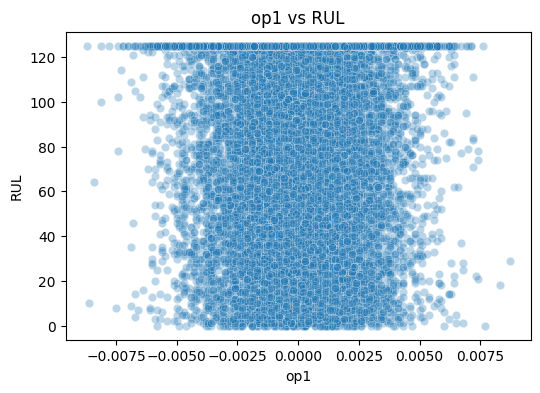

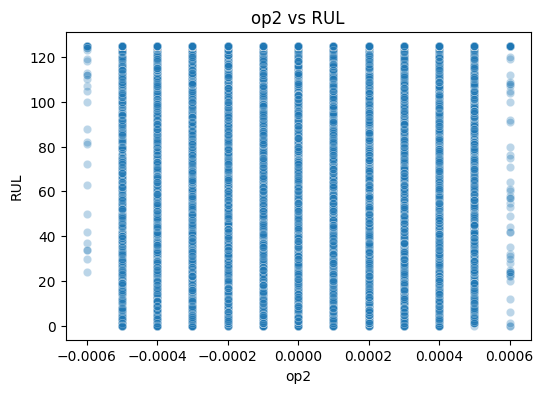

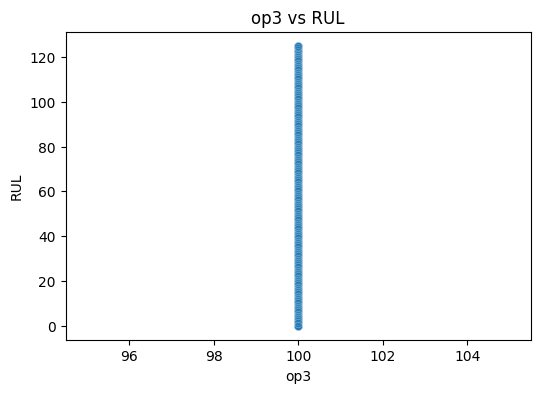

In [17]:
for op in ['op1','op2','op3']:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=train, x=op, y='RUL', alpha=0.3)
    plt.title(f"{op} vs RUL")
    plt.show()

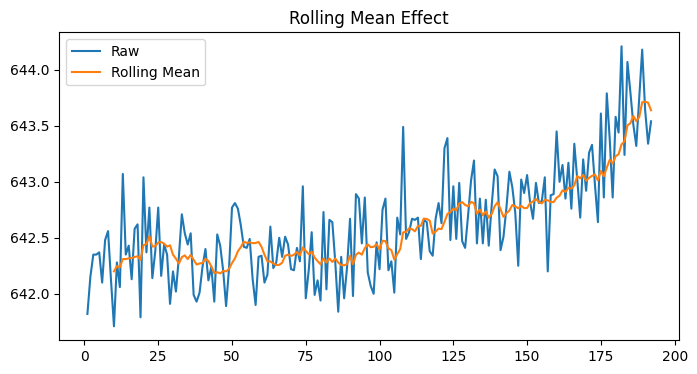

In [18]:
window = 10

train['s2_roll'] = train.groupby('unit')['s2'].rolling(window).mean().reset_index(0,drop=True)

plt.figure(figsize=(8,4))
temp = train[train['unit'] == 1]
plt.plot(temp['cycle'], temp['s2'], label='Raw')
plt.plot(temp['cycle'], temp['s2_roll'], label='Rolling Mean')
plt.legend()
plt.title("Rolling Mean Effect")
plt.show()

## **Outlier Detection (Boxplot)**

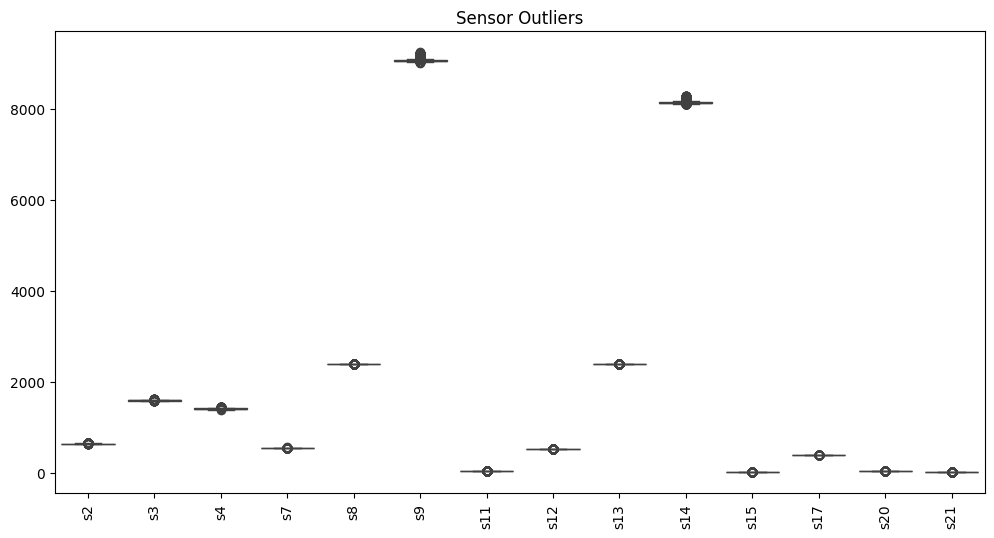

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(data=train[sensor_cols])
plt.xticks(rotation=90)
plt.title("Sensor Outliers")
plt.show()

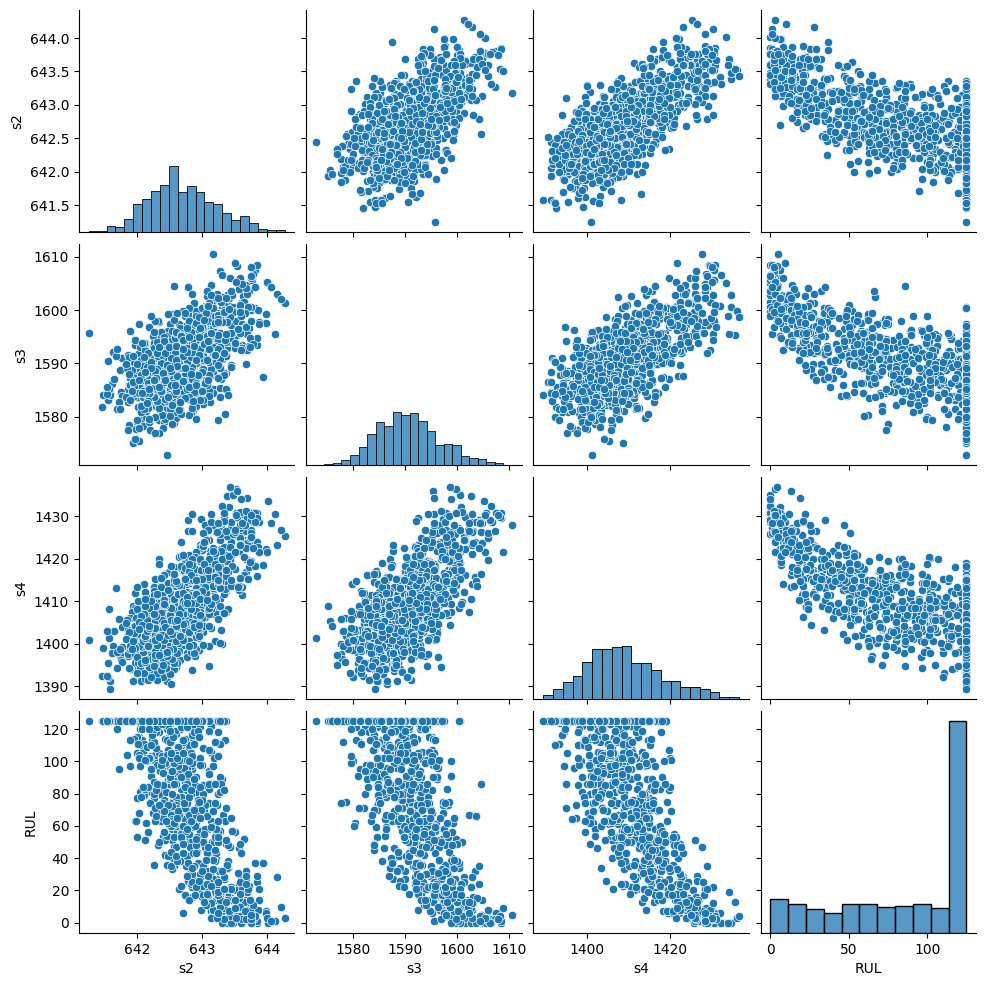

In [20]:
sample_df = train.sample(1000)
sns.pairplot(sample_df[['s2','s3','s4','RUL']])
plt.show()

# **Pre Processing Data**

In [21]:
train.head()

,unit,cycle,op1,op2,op3,s2,s3,s4,s7,s8,...,s12,s13,s14,s15,s17,s20,s21,max_cycle,RUL,s2_roll
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,...,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192,125,NaN
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,...,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192,125,NaN
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,...,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192,125,NaN
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,...,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192,125,NaN
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,...,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192,125,NaN


In [22]:
cols = ['op1', 'op2', 'op3', 'max_cycle', 's2_roll']
train.drop(columns=cols, inplace=True)

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train[sensor_cols] = scaler.fit_transform(train[sensor_cols])
test[sensor_cols]  = scaler.transform(test[sensor_cols])

In [24]:
def make_windows(df, window=30, sensor_cols=sensor_cols):
    X, y, units = [], [], []
    for unit_id, group in df.groupby('unit'):
        group = group.sort_values('cycle')
        data = group[sensor_cols].values
        rul  = group['RUL'].values
        for i in range(len(data) - window + 1):
            X.append(data[i:i+window])        # shape: (W, n_sensors)
            y.append(rul[i + window - 1])     # RUL at the last timestep
            units.append(unit_id)
    return np.array(X), np.array(y), np.array(units)

X_win, y_win, unit_ids = make_windows(train, window=30)
print(X_win.shape)

(17731, 30, 14)


In [25]:
def last_window(df, window=30):
    seqs = []
    for _, group in df.groupby('unit'):
        data = group[sensor_cols].values
        if len(data) >= window:
            seqs.append(data[-window:])
        else:
            pad = np.zeros((window - len(data), data.shape[1]))
            seqs.append(np.vstack([pad, data]))
    return np.array(seqs)

X_test_win = last_window(test)

In [26]:
X_test_win.shape # (100 cycles, 30 timesteps, 14 sensors) for FD001

(100, 30, 14)

# **BaseLine Models**

## **Linear Regression**

In [27]:
X_flat = X_win.reshape(len(X_win), -1)  # (N, 30 * n_sensors)
X_test_flat = X_test_win.reshape(len(X_test_win), -1)

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_flat, y_win)

lr_train_preds = lr.predict(X_flat).clip(0, 125)
lr_test_preds = lr.predict(X_test_flat).clip(0, 125)

lr_train_rmse = np.sqrt(mean_squared_error(y_win, lr_train_preds))
lr_test_rmse  = np.sqrt(mean_squared_error(y_test['RUL'], lr_test_preds))

lr_train_mae = mean_absolute_error(y_win, lr_train_preds)
lr_test_mae  = mean_absolute_error(y_test['RUL'], lr_test_preds)

print(f"Linear Regression: ")
print(f"Train MAE : {lr_train_mae:.2f} | RMSE: {lr_train_rmse:.2f}")
print(f"Test  MAE : {lr_test_mae:.2f} | RMSE: {lr_test_rmse:.2f}")

Linear Regression: 
Train MAE : 12.61 | RMSE: 15.66
Test  MAE : 13.00 | RMSE: 16.02


In [29]:
frame = pd.DataFrame({
    'Unit': np.arange(1, len(lr_test_preds) + 1),
    'Predicted_RUL': lr_test_preds,
    'True_RUL': y_test['RUL'].values
})

frame.head()

,Unit,Predicted_RUL,True_RUL
0,1,110.910146,112
1,2,113.759044,98
2,3,66.710161,69
3,4,85.144357,82
4,5,93.373036,91


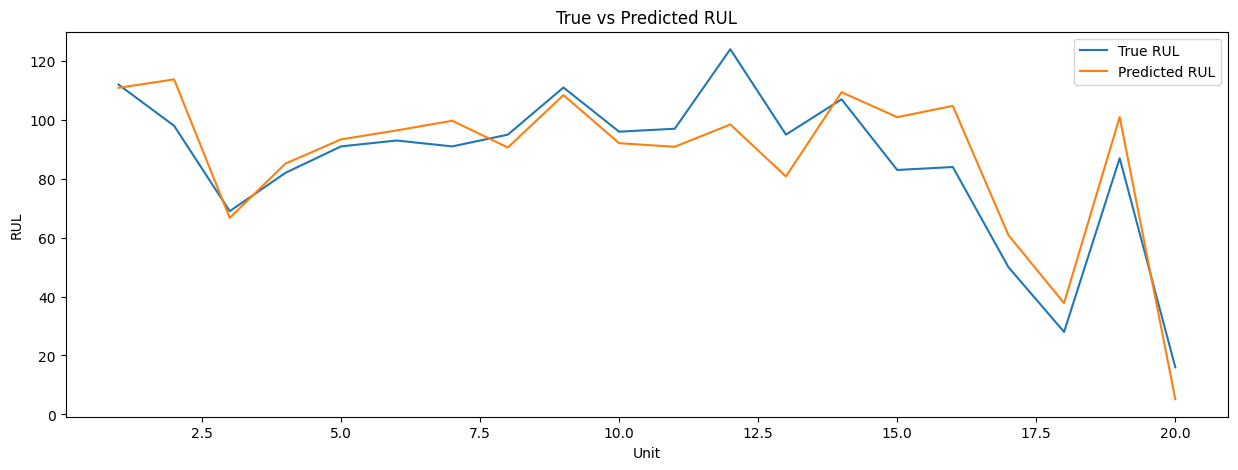

In [30]:
plt.figure(figsize=(15, 5))

sns.lineplot(data=frame[:20], x='Unit', y='True_RUL', label='True RUL')
sns.lineplot(data=frame[:20], x='Unit', y='Predicted_RUL', label='Predicted RUL')
plt.title("True vs Predicted RUL")
plt.xlabel("Unit")
plt.ylabel("RUL")
plt.legend()
plt.show()


## **SVM**

### Using PCA

In [31]:
# PCA
from sklearn.decomposition import PCA
from sklearn.svm import SVR

pca = PCA(n_components=0.50)
X_pca = pca.fit_transform(X_flat)
X_test_pca = pca.transform(X_test_flat)

svr = SVR(kernel='rbf', C=10, epsilon=1)
svr.fit(X_pca, y_win)

test_preds_svr = svr.predict(X_test_pca)
train_preds_svr = svr.predict(X_pca)

In [32]:
svr_train_rmse = np.sqrt(mean_squared_error(y_win, train_preds_svr))
svr_test_rmse  = np.sqrt(mean_squared_error(y_test['RUL'], test_preds_svr))

svr_train_mae = mean_absolute_error(y_win, lr_train_preds)
svr_test_mae  = mean_absolute_error(y_test['RUL'], lr_test_preds)

print("SVR (Linear):")
print(f"Train MAE : {svr_train_mae:.2f} | RMSE: {svr_train_rmse:.2f}")
print(f"Test  MAE : {svr_test_mae:.2f} | RMSE: {svr_test_rmse:.2f}")

SVR (Linear):
Train MAE : 12.61 | RMSE: 25.45
Test  MAE : 13.00 | RMSE: 27.83


### without PCA

In [33]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=10, gamma='scale', epsilon=1)

svr.fit(X_flat, y_win)

train_preds_svr = svr.predict(X_flat).clip(0, 125)
test_preds_svr  = svr.predict(X_test_flat).clip(0, 125)

svr_train_rmse = np.sqrt(mean_squared_error(y_win, train_preds_svr))
svr_test_rmse  = np.sqrt(mean_squared_error(y_test['RUL'], test_preds_svr))

svr_train_mae = mean_absolute_error(y_win, train_preds_svr)
svr_test_mae  = mean_absolute_error(y_test['RUL'], test_preds_svr)

print("SVR (Linear):")
print(f"Train MAE : {svr_train_mae:.2f} | RMSE: {svr_train_rmse:.2f}")
print(f"Test  MAE : {svr_test_mae:.2f} | RMSE: {svr_test_rmse:.2f}")

SVR (Linear):
Train MAE : 8.99 | RMSE: 12.75
Test  MAE : 11.31 | RMSE: 14.82


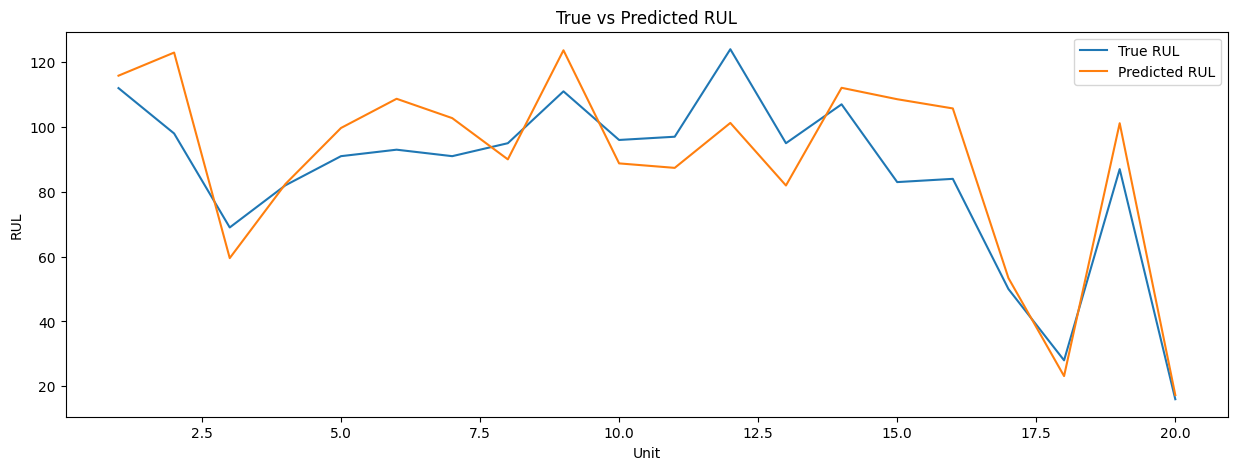

In [34]:
frame = pd.DataFrame({
    'Unit': np.arange(1, len(test_preds_svr) + 1),
    'Predicted_RUL': test_preds_svr,
    'True_RUL': y_test['RUL'].values
})

plt.figure(figsize=(15, 5))

sns.lineplot(data=frame[:20], x='Unit', y='True_RUL', label='True RUL')
sns.lineplot(data=frame[:20], x='Unit', y='Predicted_RUL', label='Predicted RUL')
plt.title("True vs Predicted RUL")
plt.xlabel("Unit")
plt.ylabel("RUL")
plt.legend()
plt.show()

## **RandomForest**

In [35]:
from sklearn.ensemble import RandomForestRegressor

rf_constrained = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=10,
    max_features=0.3,
    random_state=42,
    n_jobs=-1
)

rf_constrained.fit(X_flat, y_win)

train_preds_c = rf_constrained.predict(X_flat).clip(0, 125)
test_preds_c  = rf_constrained.predict(X_test_flat).clip(0, 125)

rf_train_rmse = np.sqrt(mean_squared_error(y_win, train_preds_c))
rf_test_rmse  = np.sqrt(mean_squared_error(y_test['RUL'], test_preds_c))

rf_train_mae = mean_absolute_error(y_win, train_preds_c)
rf_test_mae  = mean_absolute_error(y_test['RUL'], test_preds_c)

print("Random Forest:")
print(f"Train MAE : {rf_train_mae:.2f} | RMSE: {rf_train_rmse:.2f}")
print(f"Test  MAE : {rf_test_mae:.2f} | RMSE: {rf_test_rmse:.2f}")

Random Forest:
Train MAE : 10.94 | RMSE: 14.30
Test  MAE : 13.01 | RMSE: 17.54


In [36]:
frame = pd.DataFrame({
    'Unit': np.arange(1, len(test_preds_c) + 1),
    'Predicted_RUL': test_preds_c,
    'True_RUL': y_test['RUL'].values
})

frame.head()

,Unit,Predicted_RUL,True_RUL
0,1,116.509005,112
1,2,109.472651,98
2,3,62.169317,69
3,4,96.155127,82
4,5,96.353879,91


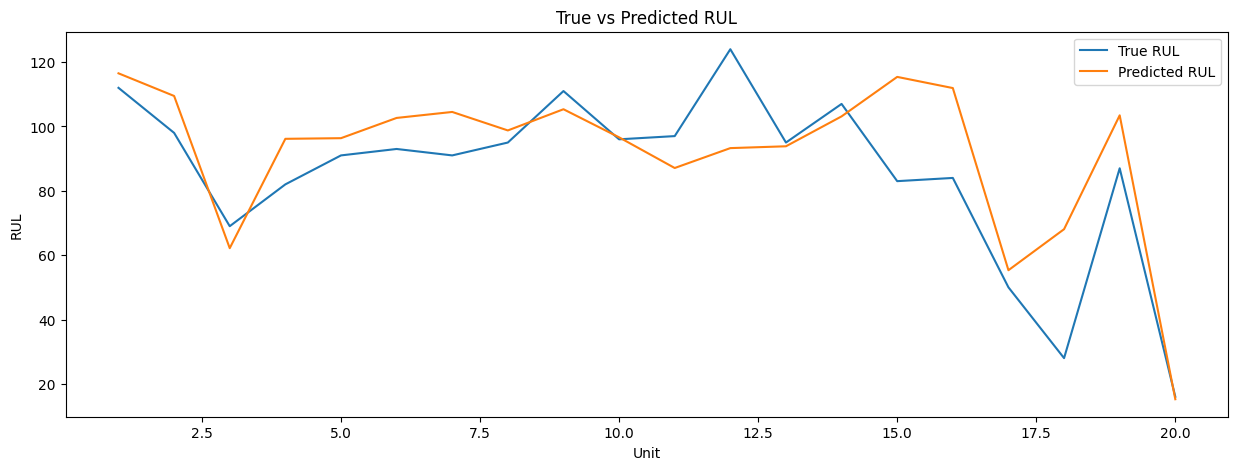

In [37]:
plt.figure(figsize=(15, 5))

sns.lineplot(data=frame[:20], x='Unit', y='True_RUL', label='True RUL')
sns.lineplot(data=frame[:20], x='Unit', y='Predicted_RUL', label='Predicted RUL')
plt.title("True vs Predicted RUL")
plt.xlabel("Unit")
plt.ylabel("RUL")
plt.legend()
plt.show()


## **Results**

In [38]:
results = pd.DataFrame({
    'Units': np.arange(1, len(test_preds_c) + 1),
    'Linear_Pred': lr_test_preds,
    'SVR_Pred': test_preds_svr,
    'RF_Pred': test_preds_c,
    'True_RUL': y_test['RUL'].values
})

In [39]:
def plot_results(results, n):
    y_cols = [col for col in results.columns if col != 'Units']

    fig = px.line(
        results[:n],
        x='Units',
        y=y_cols,
        title='Model Comparison: RUL Prediction'
    )

    fig.update_layout(
        xaxis_title='Unit',
        yaxis_title='RUL',
        legend_title='Legend',
        template='plotly_dark'
    )

    fig.show()

plot_results(results, n=20)

In [40]:
results_table = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR'],
    'MAE':   [lr_test_mae, rf_test_mae, svr_test_mae],
    'RMSE':  [lr_test_rmse, rf_test_rmse, svr_test_rmse]
})

# Optional: sort by best RMSE
results_table = results_table.sort_values(by='RMSE')

print("Model Performance Comparison: ")
print(results_table)

Model Performance Comparison: 
               Model        MAE       RMSE
2                SVR  11.313304  14.824341
0  Linear Regression  13.000982  16.018254
1      Random Forest  13.008658  17.539688


# **Deep Learning Models**

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## **Vanilla DNN**

In [48]:
# Build model
def build_dnn(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.2),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(64, activation='relu'),
        Dropout(0.1),

        Dense(1, activation='linear')   # RUL is continuous
    ])

    loss = tf.keras.losses.Huber()
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=loss,
        metrics=['mae']
    )
    return model

dnn = build_dnn(X_flat.shape[1])
dnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │       107,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,529 (588.00 KB)

 Trainable params: 149,761 (585.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [49]:
# Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Train
history = dnn.fit(
    X_flat, y_win,
    validation_split=0.15,
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 77.9045 - mae: 78.4025 - val_loss: 80.3737 - val_mae: 80.8715 - learning_rate: 1.0000e-04
Epoch 2/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 75.6914 - mae: 76.1898 - val_loss: 79.2231 - val_mae: 79.7212 - learning_rate: 1.0000e-04
Epoch 3/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 73.0448 - mae: 73.5427 - val_loss: 76.8093 - val_mae: 77.3072 - learning_rate: 1.0000e-04
Epoch 4/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 69.4536 - mae: 69.9509 - val_loss: 72.7331 - val_mae: 73.2316 - learning_rate: 1.0000e-04
Epoch 5/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 65.0197 - mae: 65.5161 - val_loss: 67.0964 - val_mae: 67.5934 - learning_rate: 1.0000e-04
Epoch 6/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 60.2497 - mae: 60.7456 - val_loss: 61.7407 - val_mae: 62.2372 - learning_rate: 1.0000e-04
Epoch 7/100
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 55.4189 - mae: 55.9145 - val_loss: 55.2692 - v

In [50]:
# Predict & clip
dnn_train_preds = dnn.predict(X_flat).flatten().clip(0, 125)
dnn_test_preds  = dnn.predict(X_test_flat).flatten().clip(0, 125)

# Metrics
dnn_train_rmse = np.sqrt(mean_squared_error(y_win, dnn_train_preds))
dnn_test_rmse  = np.sqrt(mean_squared_error(y_test['RUL'], dnn_test_preds))

dnn_test_mae = mean_absolute_error(y_test['RUL'], dnn_test_preds)
dnn_train_mae = mean_absolute_error(y_win, dnn_train_preds)

print("Vanilla DNN:")
print(f"Train MAE : {dnn_train_mae:.2f} | RMSE: {dnn_train_rmse:.2f}")
print(f"Test  MAE : {dnn_test_mae:.2f} | RMSE: {dnn_test_rmse:.2f}")

555/555 ━━━━━━━━━━━━━━━━━━━━ 1s 933us/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Vanilla DNN:
Train MAE : 9.09 | RMSE: 12.76
Test  MAE : 10.92 | RMSE: 14.45


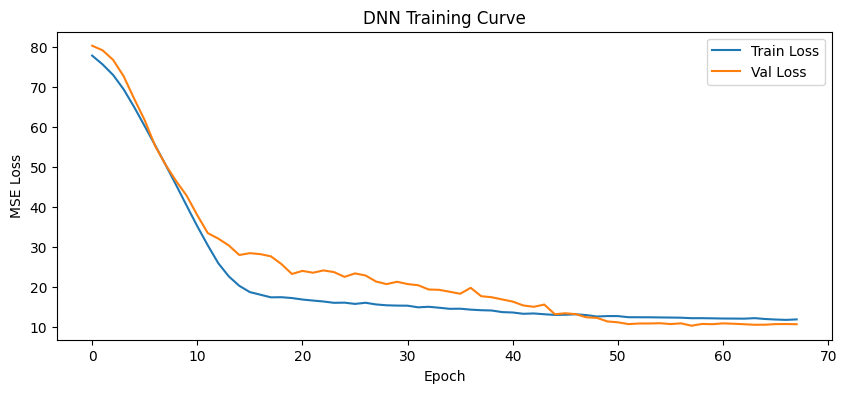

In [51]:
# Training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("DNN Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

## **Results**

In [52]:
# Add DNN to comparison plot
results['DNN_Pred'] = dnn_test_preds

plot_results(results, n=20)

In [53]:
new_row = pd.DataFrame({'Model': ['DNN'], 'MAE': dnn_test_mae, 'RMSE': dnn_test_rmse})

df = pd.concat([results_table, new_row], ignore_index=True)

df = df.sort_values(by='RMSE')
df

,Model,MAE,RMSE
3,DNN,10.924104,14.451663
0,SVR,11.313304,14.824341
1,Linear Regression,13.000982,16.018254
2,Random Forest,13.008658,17.539688


## **Engine wise prediction**

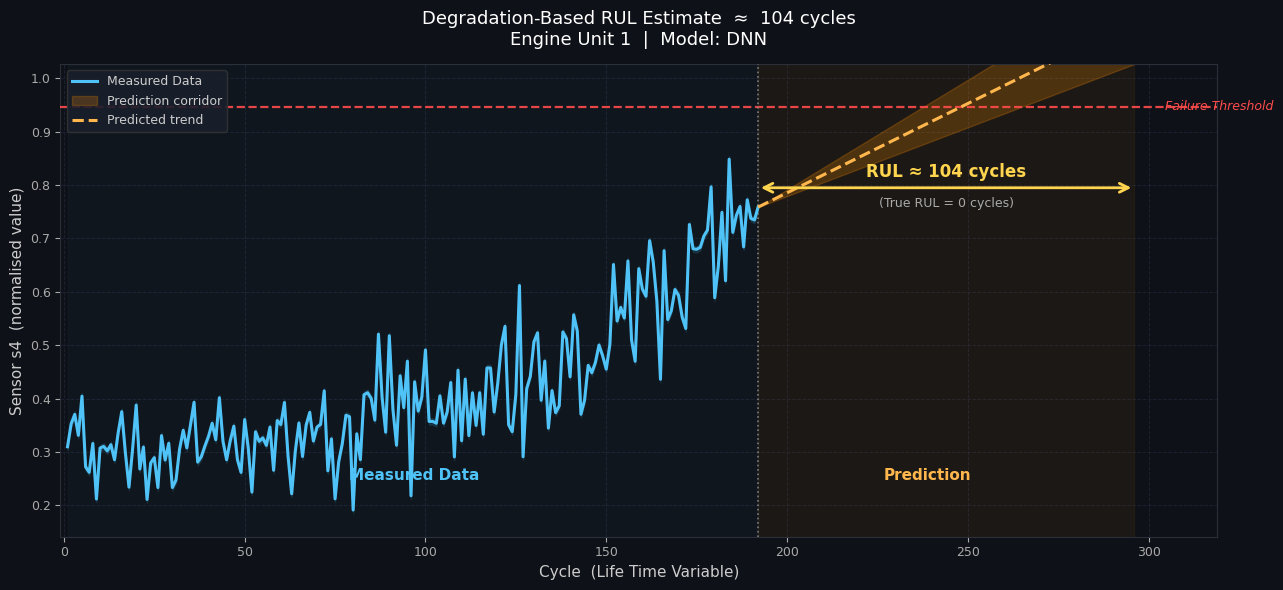

Unit 1 | Predicted RUL: 104 | True RUL: 0 | Error: 104 cycles


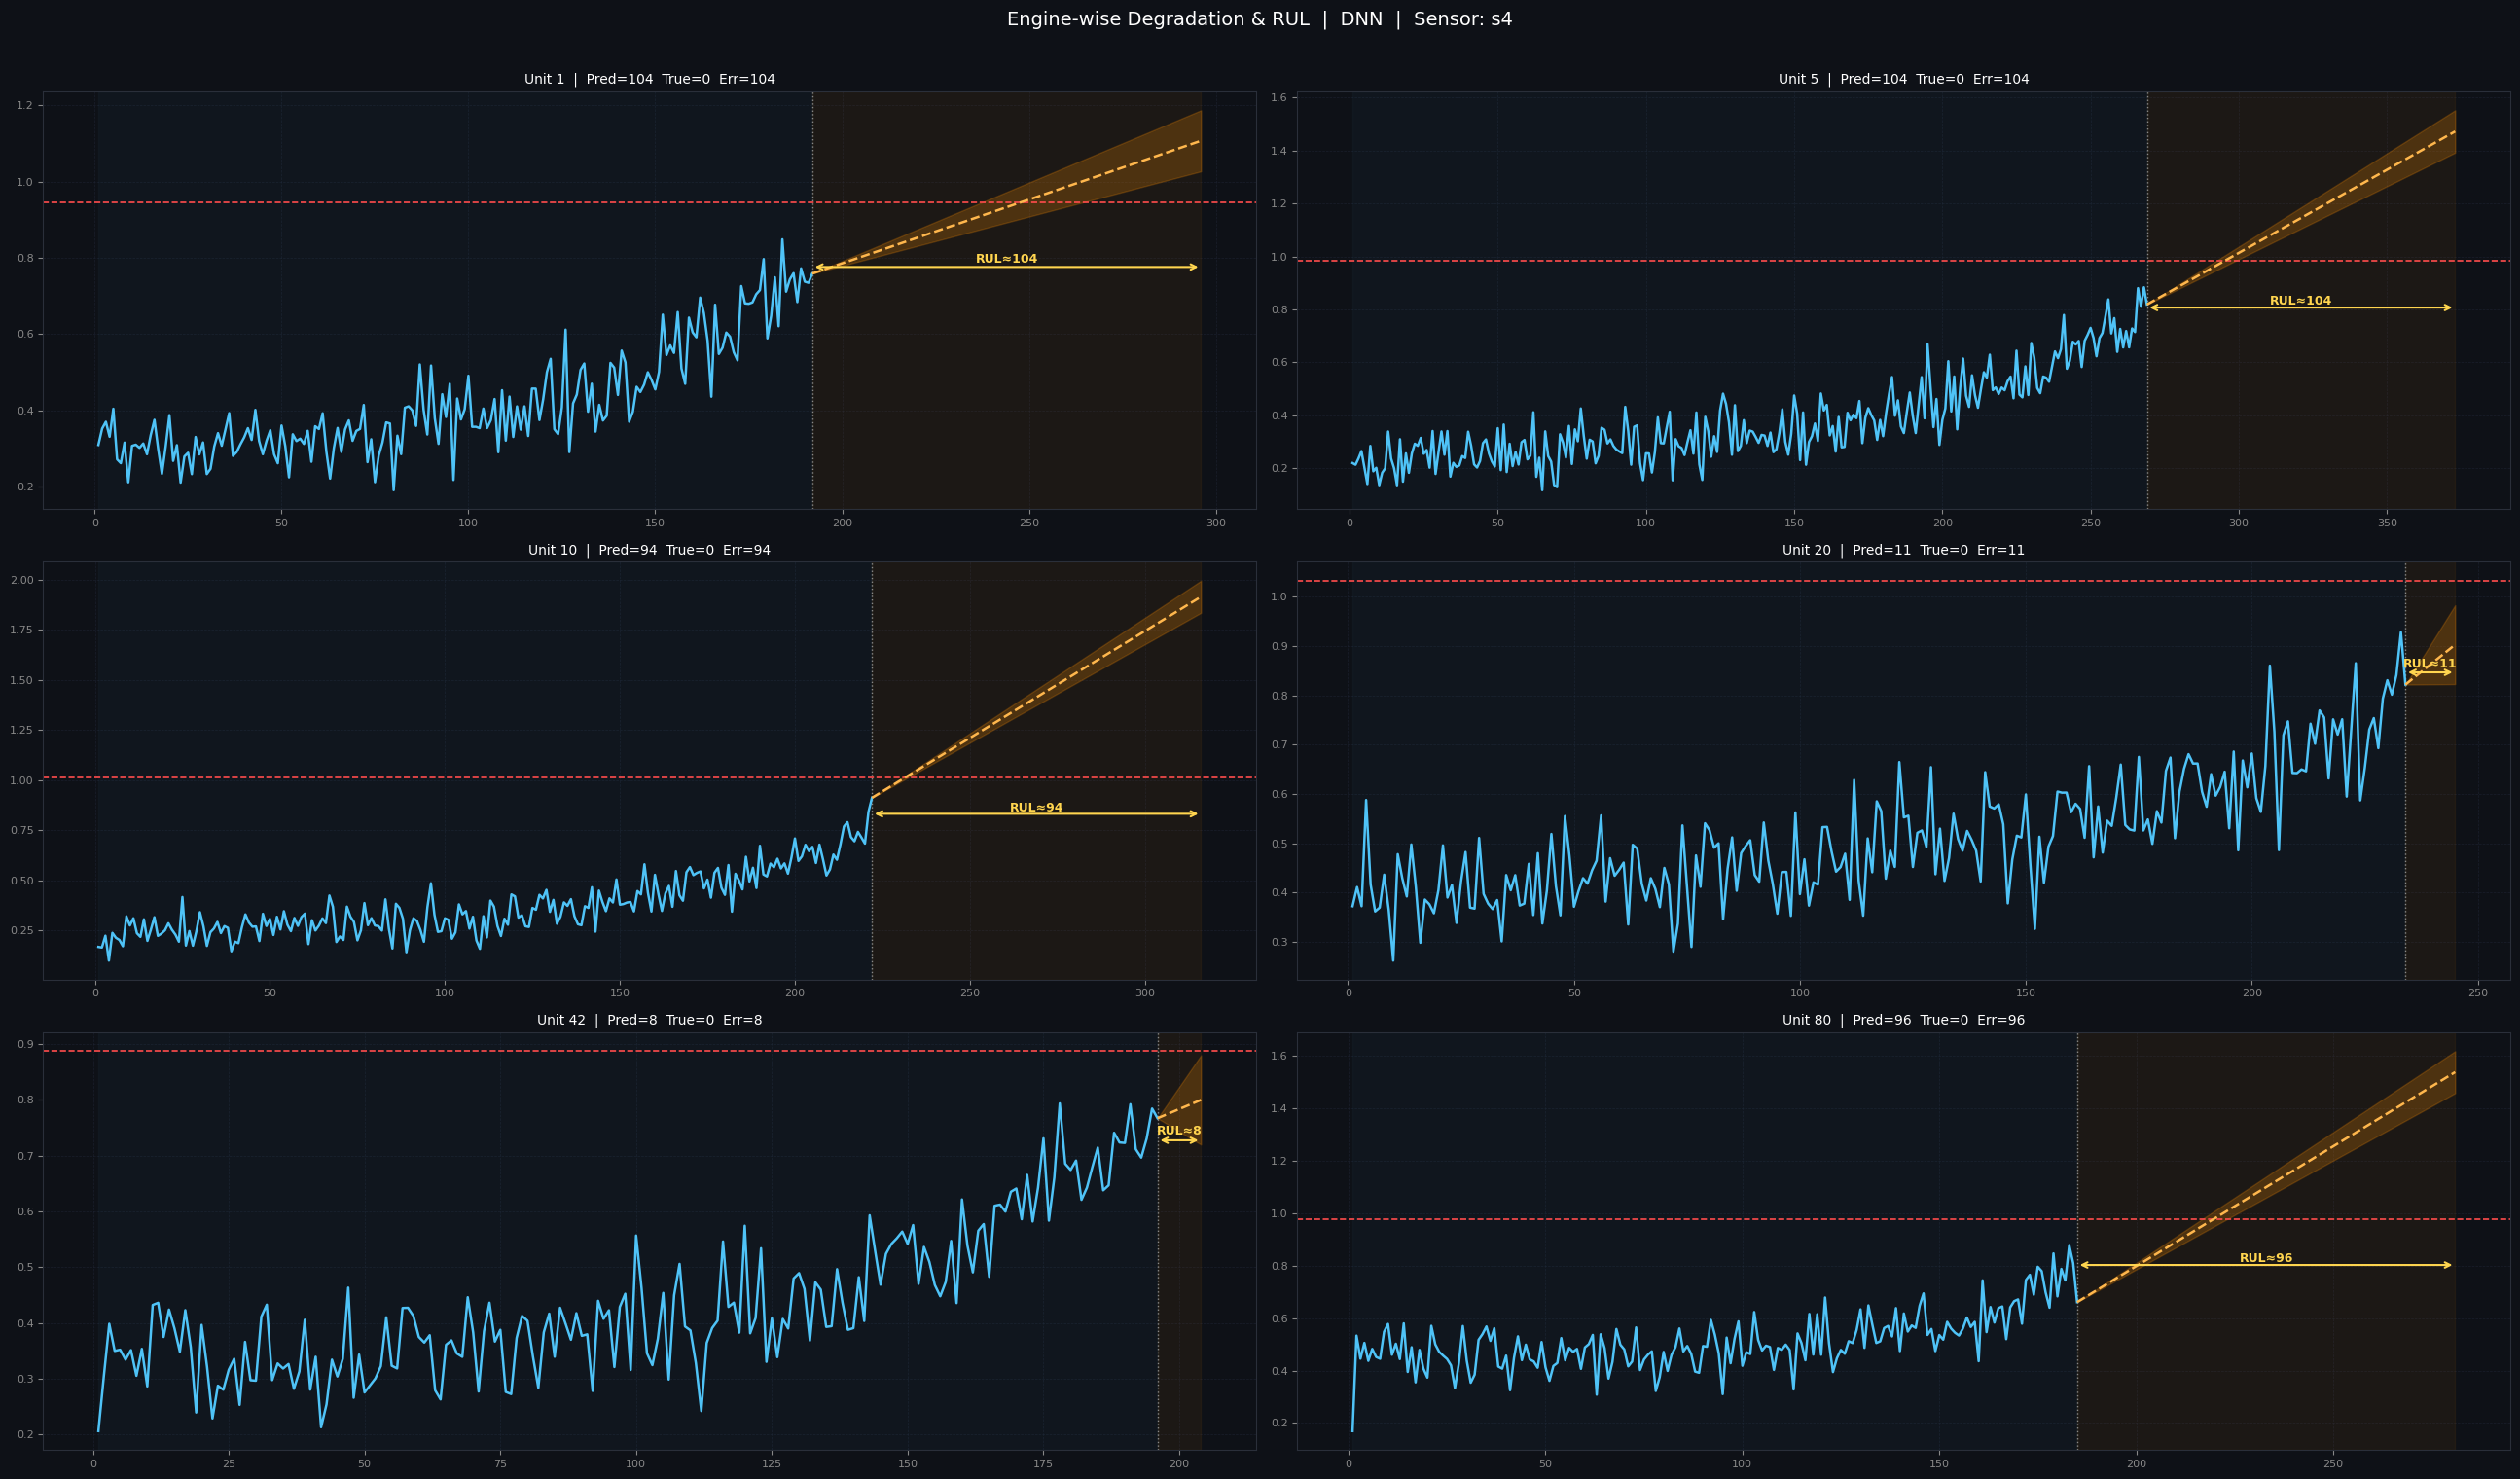

In [ ]:
# ── Engine-wise Degradation Plot ─────────────────────────────────────────────
# Paste this right after your "Engine wise prediction" section
# Works with: train, test, y_test, sensor_cols, dnn (swap any model)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_rul_degradation(unit_id, model, model_name='Model',
                         sensor='s4', window=30):
    """
    Recreates the degradation-based RUL plot from your reference image.
    Uses your existing globals: train, test, y_test, sensor_cols.
    """

    # ── Pull observed history from train ─────────────────────────────────────
    unit_train  = train[train['unit'] == unit_id].sort_values('cycle')
    cycles_obs  = unit_train['cycle'].values
    sensor_obs  = unit_train[sensor].values          # already scaled

    max_cycle   = int(cycles_obs[-1])
    true_rul    = int(unit_train['RUL'].values[-1])

    # ── Get model's predicted RUL for this unit ───────────────────────────────
    unit_test = test[test['unit'] == unit_id].sort_values('cycle')
    data      = unit_test[sensor_cols].values

    # Build the last-window sequence
    if len(data) >= window:
        seq = data[-window:]
    else:
        pad = np.zeros((window - len(data), data.shape[1]))
        seq = np.vstack([pad, data])

    # Handle both flat models (DNN/LR) and sequence models (LSTM/CNN)
    if len(model.input_shape) == 2:          # flat: (batch, features)
        x_in = seq.reshape(1, -1)
    else:                                     # sequence: (batch, T, F)
        x_in = seq[np.newaxis]

    pred_rul = float(model.predict(x_in, verbose=0).flatten()[0])
    pred_rul = int(np.clip(pred_rul, 0, 125))

    # ── Project future sensor trend ───────────────────────────────────────────
    n_slope      = min(20, len(sensor_obs))
    slope        = np.polyfit(np.arange(n_slope),
                              sensor_obs[-n_slope:], 1)[0]

    future_len   = pred_rul + 1
    future_cyc   = np.arange(max_cycle, max_cycle + future_len)
    trend        = sensor_obs[-1] + slope * np.arange(future_len)

    # Uncertainty band widens with prediction horizon
    sigma        = np.linspace(0, 0.04, future_len)
    upper        = trend + 2 * sigma
    lower        = trend - 2 * sigma

    # Failure threshold: slightly above the historical max
    fail_thresh  = sensor_obs.max() * 1.08 + 0.03

    # ── Figure setup ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(13, 6))
    fig.patch.set_facecolor('#0e1117')
    ax.set_facecolor('#0e1117')

    ax.grid(color='#1f2535', linewidth=0.7, linestyle='--', alpha=0.8)
    ax.set_axisbelow(True)

    # ── Failure threshold line ────────────────────────────────────────────────
    x_end = max_cycle + pred_rul + 8
    ax.axhline(fail_thresh, color='#ff4c4c', linewidth=1.6,
               linestyle='--', alpha=0.9, zorder=3)
    ax.text(x_end + 0.5, fail_thresh, 'Failure Threshold',
            color='#ff4c4c', fontsize=9, va='center', ha='left', style='italic')

    # ── Observed sensor data (blue) ───────────────────────────────────────────
    ax.plot(cycles_obs, sensor_obs, color='#4fc3f7',
            linewidth=2.2, zorder=5, label='Measured Data')
    ax.fill_between(cycles_obs,
                    sensor_obs - 0.006, sensor_obs + 0.006,
                    color='#4fc3f7', alpha=0.12)

    # ── "Now" divider ─────────────────────────────────────────────────────────
    y_min = min(sensor_obs.min(), lower.min()) - 0.05
    y_max = fail_thresh + 0.08
    ax.axvline(max_cycle, color='#888888', linewidth=1.2,
               linestyle=':', alpha=0.9, zorder=4)

    # ── Prediction shading (orange) ───────────────────────────────────────────
    ax.fill_between(future_cyc, lower, upper,
                    color='#ff8f00', alpha=0.22, zorder=2,
                    label='Prediction corridor')

    # Central trend line
    ax.plot(future_cyc, trend, color='#ffb74d', linewidth=2.2,
            linestyle='--', zorder=5, label='Predicted trend')

    # ── RUL span arrow ────────────────────────────────────────────────────────
    y_arrow = fail_thresh * 0.84
    ax.annotate('', xy=(max_cycle + pred_rul, y_arrow),
                xytext=(max_cycle, y_arrow),
                arrowprops=dict(arrowstyle='<->', color='#ffd54f',
                                lw=2.0, mutation_scale=16),
                zorder=6)
    ax.text(max_cycle + pred_rul / 2, y_arrow + 0.012,
            f'RUL ≈ {pred_rul} cycles',
            color='#ffd54f', fontsize=12, fontweight='bold',
            ha='center', va='bottom', zorder=7)

    # True RUL label underneath arrow
    ax.text(max_cycle + pred_rul / 2, y_arrow - 0.018,
            f'(True RUL = {true_rul} cycles)',
            color='#aaaaaa', fontsize=9,
            ha='center', va='top', zorder=7)

    # ── Region labels ─────────────────────────────────────────────────────────
    mid_obs  = cycles_obs[len(cycles_obs) // 2]
    mid_pred = max_cycle + pred_rul * 0.45
    label_y  = y_min + (y_max - y_min) * 0.12

    ax.text(mid_obs,  label_y, 'Measured Data',
            color='#4fc3f7', fontsize=11, fontweight='bold', ha='center')
    ax.text(mid_pred, label_y, 'Prediction',
            color='#ffb74d', fontsize=11, fontweight='bold', ha='center')

    # Shaded background regions
    ax.axvspan(cycles_obs[0], max_cycle,
               color='#4fc3f7', alpha=0.03, zorder=1)
    ax.axvspan(max_cycle, max_cycle + pred_rul,
               color='#ff8f00', alpha=0.06, zorder=1)

    # ── Axes & labels ─────────────────────────────────────────────────────────
    ax.set_xlim(cycles_obs[0] - 2, x_end + 15)
    ax.set_ylim(y_min, y_max)
    ax.set_xlabel('Cycle  (Life Time Variable)', color='#cccccc', fontsize=11)
    ax.set_ylabel(f'Sensor {sensor}  (normalised value)', color='#cccccc', fontsize=11)
    ax.set_title(
        f'Degradation-Based RUL Estimate  ≈  {pred_rul} cycles\n'
        f'Engine Unit {unit_id}  |  Model: {model_name}',
        color='white', fontsize=13, pad=14
    )

    ax.tick_params(colors='#aaaaaa', labelsize=9)
    for sp in ax.spines.values():
        sp.set_edgecolor('#2a2f3a')

    legend = ax.legend(loc='upper left', facecolor='#1a1f2b',
                       edgecolor='#333', labelcolor='#cccccc',
                       fontsize=9, framealpha=0.9)

    plt.tight_layout()
    plt.show()
    print(f"Unit {unit_id} | Predicted RUL: {pred_rul} | True RUL: {true_rul} "
          f"| Error: {abs(pred_rul - true_rul)} cycles")


# ── Single engine plot ────────────────────────────────────────────────────────
plot_rul_degradation(unit_id=1, model=dnn, model_name='DNN', sensor='s4')

# ── Grid plot: multiple engines at once ───────────────────────────────────────
def plot_engine_grid(unit_ids, model, model_name='Model',
                     sensor='s4', window=30, cols=2):
    rows   = (len(unit_ids) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(13 * cols, 5 * rows),
                             facecolor='#0e1117')
    axes = axes.flatten() if rows * cols > 1 else [axes]

    for ax, uid in zip(axes, unit_ids):
        unit_train = train[train['unit'] == uid].sort_values('cycle')
        cycles_obs = unit_train['cycle'].values
        sensor_obs = unit_train[sensor].values
        max_cycle  = int(cycles_obs[-1])
        true_rul   = int(unit_train['RUL'].values[-1])

        unit_test  = test[test['unit'] == uid].sort_values('cycle')
        data       = unit_test[sensor_cols].values
        if len(data) >= window:
            seq = data[-window:]
        else:
            pad = np.zeros((window - len(data), data.shape[1]))
            seq = np.vstack([pad, data])

        x_in     = seq[np.newaxis] if len(model.input_shape) == 3 \
                   else seq.reshape(1, -1)
        pred_rul = int(np.clip(
            float(model.predict(x_in, verbose=0).flatten()[0]), 0, 125))

        n_slope   = min(20, len(sensor_obs))
        slope     = np.polyfit(np.arange(n_slope),
                               sensor_obs[-n_slope:], 1)[0]
        future    = np.arange(max_cycle, max_cycle + pred_rul + 1)
        trend     = sensor_obs[-1] + slope * np.arange(len(future))
        sigma     = np.linspace(0, 0.04, len(future))
        fail_th   = sensor_obs.max() * 1.08 + 0.03

        ax.set_facecolor('#0e1117')
        ax.grid(color='#1f2535', linewidth=0.5, linestyle='--', alpha=0.7)
        ax.set_axisbelow(True)

        ax.axhline(fail_th, color='#ff4c4c', linewidth=1.2, linestyle='--')
        ax.axvline(max_cycle, color='#888', linewidth=1, linestyle=':')
        ax.axvspan(cycles_obs[0], max_cycle,  color='#4fc3f7', alpha=0.03)
        ax.axvspan(max_cycle, max_cycle + pred_rul, color='#ff8f00', alpha=0.06)

        ax.plot(cycles_obs, sensor_obs, color='#4fc3f7', linewidth=1.8)
        ax.fill_between(future, trend - 2*sigma, trend + 2*sigma,
                        color='#ff8f00', alpha=0.22)
        ax.plot(future, trend, color='#ffb74d', linewidth=1.8, linestyle='--')

        # Mini RUL arrow
        y_arr = fail_th * 0.82
        if pred_rul > 2:
            ax.annotate('', xy=(max_cycle + pred_rul, y_arr),
                        xytext=(max_cycle, y_arr),
                        arrowprops=dict(arrowstyle='<->', color='#ffd54f', lw=1.5))
        ax.text(max_cycle + pred_rul / 2, y_arr + 0.01,
                f'RUL≈{pred_rul}', color='#ffd54f',
                fontsize=9, fontweight='bold', ha='center')

        ax.set_title(f'Unit {uid}  |  Pred={pred_rul}  True={true_rul}  '
                     f'Err={abs(pred_rul-true_rul)}',
                     color='white', fontsize=10)
        ax.tick_params(colors='#888', labelsize=8)
        for sp in ax.spines.values(): sp.set_edgecolor('#2a2f3a')

    # Hide unused subplots
    for ax in axes[len(unit_ids):]:
        ax.set_visible(False)

    fig.suptitle(f'Engine-wise Degradation & RUL  |  {model_name}  |  Sensor: {sensor}',
                 color='white', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'engine_grid_{model_name}.png', dpi=150,
                bbox_inches='tight', facecolor='#0e1117')
    plt.show()


# Plot 6 engines in a 2-column grid
plot_engine_grid(
    unit_ids   = [1, 5, 10, 20, 42, 80],
    model      = dnn,
    model_name = 'DNN',
    sensor     = 's4',
    cols       = 2
)